In [5]:
# =========================== Cell -1: Environment Bootstrap (Colab) ===========================
# Installs + runtime checks for the advanced MRI pipeline (EffNetB3 + MixUp/CutMix + XGBoost/CatBoost)

# --- Install Python packages (kept lean for Colab Free) ---
!pip -q install --upgrade pip
!pip -q install xgboost catboost imagehash opencv-python-headless==4.10.0.84

# --- Imports & version printouts ---
import sys, platform, subprocess, os
import numpy as np
import tensorflow as tf
import sklearn
import pandas as pd
import matplotlib
import PIL
import cv2
import xgboost as xgb
from catboost import CatBoostClassifier
import imagehash

print("✅ Versions")
print(f"Python           : {sys.version.split()[0]}  ({platform.platform()})")
print(f"TensorFlow       : {tf.__version__}")
print(f"NumPy            : {np.__version__}")
print(f"scikit-learn     : {sklearn.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Pillow (PIL)     : {PIL.__version__}")
print(f"OpenCV           : {cv2.__version__}")
print(f"XGBoost          : {xgb.__version__}")
print(f"CatBoost         : {CatBoostClassifier.__module__.split('.')[0]} (import ok)")
print(f"ImageHash        : {imagehash.__version__}")

# --- GPU / VRAM check ---
print("\n✅ GPU Check")
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for i, g in enumerate(gpus):
            details = tf.config.experimental.get_device_details(g)
            name = details.get('device_name', 'GPU')
            print(f"  • GPU {i}: {name}")
        # Show free VRAM via nvidia-smi if available
        try:
            smi = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total,memory.free',
                                           '--format=csv,noheader,nounits']).decode().strip().splitlines()
            for i, line in enumerate(smi):
                name, mem_total, mem_free = [x.strip() for x in line.split(',')]
                print(f"  • nvidia-smi {i}: {name} | VRAM total: {mem_total} MB | free: {mem_free} MB")
        except Exception:
            pass
    else:
        print("  • No GPU detected. In Colab, go to Runtime → Change runtime type → GPU.")
except Exception as e:
    print("  • GPU check error:", e)

# --- Enable mixed precision (speeds up training & reduces VRAM) ---
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("\n✅ Mixed precision: ENABLED (float16 compute / float32 outputs)")
except Exception as e:
    print("\n⚠️ Mixed precision not enabled:", e)

# --- Set a couple of TF runtime niceties ---
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TF log noise
tf.config.optimizer.set_jit(True)          # XLA can speed up on some models

print("\n✅ Bootstrap complete. You’re ready to run Cell 0 (setup & Drive mount).")
# ===============================================================================================


✅ Versions
Python           : 3.12.11  (Linux-6.1.123+-x86_64-with-glibc2.35)
TensorFlow       : 2.19.0
NumPy            : 2.0.2
scikit-learn     : 1.6.1
Pandas           : 2.2.2
Matplotlib       : 3.10.0
Pillow (PIL)     : 11.3.0
OpenCV           : 4.10.0
XGBoost          : 3.0.4
CatBoost         : catboost (import ok)
ImageHash        : 4.3.2

✅ GPU Check
  • GPU 0: Tesla T4
  • nvidia-smi 0: Tesla T4 | VRAM total: 15360 MB | free: 15092 MB

✅ Mixed precision: ENABLED (float16 compute / float32 outputs)

✅ Bootstrap complete. You’re ready to run Cell 0 (setup & Drive mount).


In [6]:
# 📦 DATASET DOWNLOAD - Fetching from Kaggle
import os

# Install Kaggle API
!pip install kaggle --upgrade --quiet

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Copy the kaggle.json to the created folder
# NOTE: You must upload your kaggle.json file to Colab first.
# Go to "Files" tab (folder icon on the left panel), click "Upload to session storage" (arrow up icon),
# and upload your kaggle.json file.
# Alternatively, you can use Google Drive if you have kaggle.json there:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/My Drive/kaggle.json" ~/.kaggle/

# Check if kaggle.json exists in the expected location before copying
if os.path.exists("/kaggle/kaggle.json"):
  print("kaggle.json found in /kaggle/.")
  !cp "/kaggle/kaggle.json" ~/.kaggle/
  # Give permissions to the json file
  !chmod 600 ~/.kaggle/kaggle.json
  kaggle_auth_successful = True
elif os.path.exists("/content/kaggle.json"):
   print("kaggle.json found in /content/.")
   !cp "/content/kaggle.json" ~/.kaggle/
   # Give permissions to the json file
   !chmod 600 ~/.kaggle/kaggle.json
   kaggle_auth_successful = True
else:
  print("Warning: kaggle.json not found in /kaggle/ or /content/. Please upload it or check your path.")
  kaggle_auth_successful = False


if kaggle_auth_successful:
    # Download the dataset
    # The dataset slug is found on the Kaggle dataset page URL:
    # https://www.kaggle.com/datasets/orvile/pmram-bangladeshi-brain-cancer-mri-dataset
    dataset_slug = 'orvile/pmram-bangladeshi-brain-cancer-mri-dataset'
    print(f"Downloading dataset: {dataset_slug}")
    # Download the zip file to /content/
    !kaggle datasets download -d {dataset_slug} -p /content/

    # Unzip the dataset
    print("Unzipping dataset...")
    # Assuming the zip file is named after the dataset slug
    zip_file_path = f'/content/{dataset_slug.split("/")[-1]}.zip'
    if os.path.exists(zip_file_path):
        # Use -o option to overwrite existing files without prompting
        !unzip -o {zip_file_path} -d /content/
        print("Dataset unzipped successfully!")

        # Verify the dataset directory structure by listing contents of /content/
        print("\n🔍 Verifying files in /content/ after unzipping...")
        !ls -l /content/

        # Identify the Correct DATASET_PATH dynamically based on unzipped content
        identified_dataset_path = None
        # Expected unzipped folder name based on the slug: pmram-bangladeshi-brain-cancer-mri-dataset
        expected_folder_name = dataset_slug.split('/')[-1]
        potential_base_path = os.path.join('/content/', expected_folder_name)

        if os.path.exists(potential_base_path):
             # Check for the common nested directory structure
             potential_nested_path = os.path.join(potential_base_path, 'PMRAM Bangladeshi Brain Cancer - MRI Dataset')
             if os.path.exists(potential_nested_path):
                 DATASET_PATH = potential_nested_path
                 print(f"✅ Found nested dataset path: {DATASET_PATH}")
             else:
                  # If nested path not found, assume data folders are directly under the base path
                 DATASET_PATH = potential_base_path
                 print(f"⚠️ Nested path not found. Assuming data folders are directly under: {DATASET_PATH}")

             globals()['DATASET_PATH'] = DATASET_PATH
             globals()['DATASET_READY'] = True # Flag to indicate dataset is ready
             globals()['CLASS_NAMES'] = ['Glioma', 'Meningioma', 'Pituitary', 'Normal'] # Ensure CLASS_NAMES is set

             print(f"\n🔧 Final DATASET_PATH set to: {DATASET_PATH}")

        else:
            DATASET_PATH = None
            globals()['DATASET_PATH'] = None
            globals()['DATASET_READY'] = False
            globals()['CLASS_NAMES'] = []
            print(f"❌ Could not identify the dataset directory '{expected_folder_name}' in /content/.")
            print("   Please manually inspect the output above and set the DATASET_PATH variable.")

    else:
        DATASET_PATH = None
        globals()['DATASET_PATH'] = None
        globals()['DATASET_READY'] = False
        globals()['CLASS_NAMES'] = []
        print(f"❌ Downloaded zip file not found at {zip_file_path}.")
        print("   Please check the download command output for errors.")

else:
    DATASET_PATH = None
    globals()['DATASET_PATH'] = None
    globals()['DATASET_READY'] = False
    globals()['CLASS_NAMES'] = []
    print("\nSkipping dataset download and unzipping due to Kaggle authentication failure.")

Streaming output truncated to the last 5000 lines.
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_1657.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_2149.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_5263.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_6089.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_322_3416.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Datas

In [7]:
# ===== Cell 0: Setup =====
!pip install -q xgboost catboost imagehash opencv-python-headless

import os, random, numpy as np, tensorflow as tf
from google.colab import drive

# Mount Drive & set run dir
drive.mount('/content/drive')
RUN_DIR = "/content/drive/MyDrive/BrainMRI_Results_Advanced"
os.makedirs(RUN_DIR, exist_ok=True)

# Data root (your dataset layout: Raw/ and Augmented/ under this path)
DATASET_ROOT = "/content/PMRAM Bangladeshi Brain Cancer - MRI Dataset"  # <- keep as-is

# Mixed precision = faster + less VRAM
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Repro
SEEDS = [42, 1001, 2027]
random.seed(SEEDS[0]); np.random.seed(SEEDS[0]); tf.random.set_seed(SEEDS[0])

print("✅ Setup ready. Saving to:", RUN_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup ready. Saving to: /content/drive/MyDrive/BrainMRI_Results_Advanced


In [8]:
# ===== Cell 1: Index + Grouped Split =====
import re, glob, pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

roots = [os.path.join(DATASET_ROOT, "Raw"), os.path.join(DATASET_ROOT, "Augmented")]
exts = (".png", ".jpg", ".jpeg")

rows = []
for root in roots:
    if not os.path.exists(root): continue
    for cls in sorted(os.listdir(root)):
        d = os.path.join(root, cls)
        if not os.path.isdir(d): continue
        for p in glob.glob(os.path.join(d, "**", "*"), recursive=True):
            if p.lower().endswith(exts):
                rows.append((p, cls))

df = pd.DataFrame(rows, columns=["path","label"])
assert len(df) > 0, "No images found. Check DATASET_ROOT."

# infer patient id from filename stem (strip common aug tokens)
def get_pid(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    stem = re.sub(r'(aug|flip|rot|noise|zoom|shift|clahe|gamma|_copy\d*|_aug\d*)', '', stem, flags=re.I)
    m = re.search(r'(\d{3,}|\d+)$', stem)
    return m.group(1) if m else stem

df["patient_id"] = df["path"].map(get_pid)
df["label_id"]   = df["label"].astype('category').cat.codes
class_names = list(df["label"].astype('category').cat.categories)
num_classes = len(class_names)
print("Classes:", class_names, "| N=", len(df), "| Patients≈", df["patient_id"].nunique())

# 80/20 group-strat split using 1st fold as test
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEEDS[0])
trval_idx, test_idx = list(sgkf.split(df, df["label_id"], groups=df["patient_id"]))[0]
df_trainval = df.iloc[trval_idx].reset_index(drop=True)
df_test     = df.iloc[test_idx].reset_index(drop=True)

# train/val split (group-aware) within trainval
sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEEDS[1])
tr_idx, va_idx = list(sgkf2.split(df_trainval, df_trainval["label_id"], groups=df_trainval["patient_id"]))[0]
df_train = df_trainval.iloc[tr_idx].reset_index(drop=True)
df_val   = df_trainval.iloc[va_idx].reset_index(drop=True)

print("Split sizes:", len(df_train), len(df_val), len(df_test))

# save splits for reproducibility
splits_dir = os.path.join(RUN_DIR, "splits"); os.makedirs(splits_dir, exist_ok=True)
df_train.to_csv(os.path.join(splits_dir, "train.csv"), index=False)
df_val.to_csv(  os.path.join(splits_dir, "val.csv"),   index=False)
df_test.to_csv( os.path.join(splits_dir, "test.csv"),  index=False)


Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary'] | N= 7509 | Patients≈ 5860
Split sizes: 4797 1197 1515


In [9]:
# ======================= Cell 2 (ROBUST): Data Pipeline + Safe MixUp/CutMix =======================
import os, numpy as np, pandas as pd, tensorflow as tf, cv2
AUTOTUNE = tf.data.AUTOTUNE

# ---- Config ----
IMG_S1, IMG_S2 = 192, 224   # progressive sizes
B1, B2 = 32, 24             # reduce if OOM
assert 'df_train' in globals() and 'df_val' in globals() and 'df_test' in globals(), "Run the split cell first."
assert 'class_names' in globals(), "class_names missing."

# ---- Map labels to ints IN PANDAS ----
label_to_id = {c:i for i,c in enumerate(class_names)}
for _df in [df_train, df_val, df_test]:
    _df["label_id"] = _df["label"].map(label_to_id).astype("int32")
num_classes = len(class_names)

# ---- I/O & preprocessing ----
def decode_gray(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, dtype=tf.dtypes.uint8, expand_animations=False)
    return img

def apply_clahe_np(x):
    arr = x[...,0]  # uint8 (H,W)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    arr = clahe.apply(arr)
    return arr[...,None]  # uint8 (H,W,1)

def preprocess_img(path, size):
    img = decode_gray(path)
    # CLAHE (toggle by commenting next 2 lines)
    img = tf.numpy_function(apply_clahe_np, [img], tf.uint8)
    img.set_shape([None, None, 1])
    img = tf.image.resize(img, (size, size), method='bilinear')   # exact size
    img = tf.cast(img, tf.float32) / 255.0
    return img

def aug_strong(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    noise = tf.random.normal(tf.shape(img), stddev=0.03, dtype=img.dtype)
    img = tf.clip_by_value(img + noise, 0., 1.)
    return img

def ds_from_df(df_sub, size, batch, training):
    paths  = df_sub["path"].values
    labels = df_sub["label_id"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df_sub), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(lambda p,l: (preprocess_img(p, size), l), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (aug_strong(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch, drop_remainder=False).prefetch(AUTOTUNE)
    return ds

# ---- Batch-safe MixUp + CutMix (mask via coordinate grid -> always HxW) ----
def mixup_cutmix(ds, num_classes, alpha=0.2, p_mixup=0.5):
    AUTOTUNE = tf.data.AUTOTUNE

    @tf.function
    def _beta_scalar():
        g1 = tf.random.gamma(shape=[], alpha=alpha, beta=1.0)
        g2 = tf.random.gamma(shape=[], alpha=alpha, beta=1.0)
        return g1 / (g1 + g2)

    def _map(x, y_int):
        # x: [B,H,W,1], y_int: [B]
        y = tf.one_hot(y_int, num_classes)                # [B,C]
        bs = tf.shape(x)[0]
        H  = tf.shape(x)[1]
        W  = tf.shape(x)[2]

        # shuffled pair
        idx = tf.random.shuffle(tf.range(bs))
        x2, y2 = tf.gather(x, idx), tf.gather(y, idx)

        use_mixup = tf.less(tf.random.uniform([]), p_mixup)

        def do_mixup():
            lam = _beta_scalar()                           # scalar
            x_m = lam * x + (1.0 - lam) * x2
            y_m = lam * y + (1.0 - lam) * y2
            return x_m, y_m

        def do_cutmix():
            lam = _beta_scalar()                           # scalar
            # box size
            cut_w = tf.cast(tf.sqrt(1.0 - lam) * tf.cast(W, tf.float32), tf.int32)
            cut_h = tf.cast(tf.sqrt(1.0 - lam) * tf.cast(H, tf.float32), tf.int32)
            cut_w = tf.clip_by_value(cut_w, 1, W)
            cut_h = tf.clip_by_value(cut_h, 1, H)

            # center
            cx = tf.random.uniform([], 0, W, dtype=tf.int32)
            cy = tf.random.uniform([], 0, H, dtype=tf.int32)

            x1 = tf.clip_by_value(cx - cut_w // 2, 0, W - 1)
            y1 = tf.clip_by_value(cy - cut_h // 2, 0, H - 1)
            x2c = tf.clip_by_value(x1 + cut_w, 1, W)
            y2c = tf.clip_by_value(y1 + cut_h, 1, H)

            # coordinate grid -> mask exactly [H,W,1]
            yy = tf.range(H)[:, None]          # [H,1]
            xx = tf.range(W)[None, :]          # [1,W]
            inside_y = tf.logical_and(yy >= y1, yy < y2c)  # [H,1]
            inside_x = tf.logical_and(xx >= x1, xx < x2c)  # [1,W]
            mask2d = tf.logical_and(inside_y, inside_x)    # [H,W]
            mask = tf.cast(mask2d, x.dtype)[None, ..., None]  # [1,H,W,1] broadcast over batch

            x_m = x * (1.0 - mask) + x2 * mask

            box_area = tf.cast((y2c - y1) * (x2c - x1), tf.float32)
            lam_eff = 1.0 - box_area / tf.cast(H * W, tf.float32)
            y_m = lam_eff * y + (1.0 - lam_eff) * y2
            return x_m, y_m

        return tf.cond(use_mixup, do_mixup, do_cutmix)

    return ds.map(_map, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# ---- Build progressive datasets ----
train_s1 = ds_from_df(df_train, IMG_S1, B1, training=True)
val_s1   = ds_from_df(df_val,   IMG_S1, B1, training=False)
train_s1 = mixup_cutmix(train_s1, num_classes, alpha=0.2, p_mixup=0.5)
val_s1   = val_s1.map(lambda x,y: (x, tf.one_hot(y, num_classes))).prefetch(AUTOTUNE)

train_s2 = ds_from_df(df_train, IMG_S2, B2, training=True)
val_s2   = ds_from_df(df_val,   IMG_S2, B2, training=False)
train_s2 = mixup_cutmix(train_s2, num_classes, alpha=0.2, p_mixup=0.5)
val_s2   = val_s2.map(lambda x,y: (x, tf.one_hot(y, num_classes))).prefetch(AUTOTUNE)

test_s2  = ds_from_df(df_test,  IMG_S2, B2, training=False)
test_s2  = test_s2.map(lambda x,y: (x, tf.one_hot(y, num_classes))).prefetch(AUTOTUNE)

# ---- Sanity prints ----
print("✅ Data pipelines ready.")
for name, ds in [("train_s1", train_s1), ("val_s1", val_s1),
                 ("train_s2", train_s2), ("val_s2", val_s2), ("test_s2", test_s2)]:
    xb, yb = next(iter(ds.take(1)))
    print(f"{name}: X{xb.shape}, y{yb.shape}")


✅ Data pipelines ready.
train_s1: X(32, 192, 192, 1), y(32, 4)
val_s1: X(32, 192, 192, 1), y(32, 4)
train_s2: X(24, 224, 224, 1), y(24, 4)
val_s2: X(24, 224, 224, 1), y(24, 4)
test_s2: X(24, 224, 224, 1), y(24, 4)


In [10]:
# =================== Cell 3 (FIXED): EfficientNetB3 progressive training ===================
import tensorflow as tf
from tensorflow.keras import layers, Model
import os

# ---- builder: Keras-safe channel tiling (grayscale -> 3ch) ----
def build_effb3(input_size, num_classes, name=None):
    inp = layers.Input((input_size, input_size, 1), name=f"inp_{input_size}")
    # Keras-native channel repeat (no raw tf.ops on KerasTensor)
    x3 = layers.Concatenate(axis=-1, name=f"tile3_{input_size}")([inp, inp, inp])

    base = tf.keras.applications.EfficientNetB3(
        include_top=False, weights="imagenet", input_tensor=x3, pooling="avg"
    )
    x = layers.Dropout(0.30, name=f"do_head1_{input_size}")(base.output)
    x = layers.Dense(512, activation='relu', name=f"dense512_{input_size}")(x)
    x = layers.Dropout(0.40, name=f"do_head2_{input_size}")(x)
    # Force float32 at the head for numerical stability under mixed precision
    out = layers.Dense(num_classes, activation='softmax', dtype='float32', name=f"cls_{input_size}")(x)
    m = Model(inp, out, name=name or f"EffB3_{input_size}")
    return m

def compile_model(m, lr=3e-4, wd=1e-4, ls=0.05):
    opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    m.compile(
        optimizer=opt,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=ls),
        metrics=['accuracy']
    )

# ---- Stage 1 @192: freeze backbone, train head ----
eff_s1 = build_effb3(IMG_S1, num_classes, name="EffB3_s1")
# freeze all EfficientNetB3 layers (identified by name)
for l in eff_s1.layers:
    if "efficientnetb3" in l.name:
        l.trainable = False
compile_model(eff_s1, lr=3e-4, wd=1e-4, ls=0.05)

cb1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(RUN_DIR, "effb3_s1.keras"),
                                       monitor='val_accuracy', save_best_only=True)
]
hist1 = eff_s1.fit(train_s1, validation_data=val_s1, epochs=12, verbose=1, callbacks=cb1)

# ---- Stage 2 @224: rebuild model, transfer compatible weights, unfreeze tail, fine-tune ----
eff_s2 = build_effb3(IMG_S2, num_classes, name="EffB3_s2")

# utility: copy weights when shapes match (safer than indexing)
def safe_transfer(src_model, dst_model):
    src_layers = {l.name: l for l in src_model.layers}
    copied = 0
    for l in dst_model.layers:
        if l.name in src_layers:
            try:
                w_src = src_layers[l.name].get_weights()
                w_dst = l.get_weights()
                if w_src and all(a.shape == b.shape for a,b in zip(w_src, w_dst)):
                    l.set_weights(w_src)
                    copied += 1
            except Exception:
                pass
    return copied

copied = safe_transfer(eff_s1, eff_s2)
print(f"Transferred {copied} layers from Stage-1 to Stage-2.")

# freeze all backbone first, then unfreeze last ~60 layers for fine-tune
for l in eff_s2.layers:
    if "efficientnetb3" in l.name:
        l.trainable = False

# find all backbone layers indices
backbone_idxs = [i for i, l in enumerate(eff_s2.layers) if "efficientnetb3" in l.name]
if backbone_idxs:
    # unfreeze last 60 backbone layers (or fewer if model smaller)
    tail_count = 60
    for i in backbone_idxs[-tail_count:]:
        eff_s2.layers[i].trainable = True

compile_model(eff_s2, lr=1e-4, wd=5e-5, ls=0.03)

cb2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(RUN_DIR, "effb3_s2.keras"),
                                       monitor='val_accuracy', save_best_only=True)
]
hist2 = eff_s2.fit(train_s2, validation_data=val_s2, epochs=16, verbose=1, callbacks=cb2)

# ---- Evaluate & expose best model ----
test_loss, test_acc = eff_s2.evaluate(test_s2, verbose=0)
print(f"✅ EffB3(192→224) — TEST acc: {test_acc:.4f}")

best_cnn = eff_s2
best_path = os.path.join(RUN_DIR, "best_cnn_effb3.keras")
best_cnn.save(best_path)
print("Saved best CNN to:", best_path)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 634s 2s/step - accuracy: 0.5545 - loss: 1.1455 - val_accuracy: 0.2590 - val_loss: 1.8743
Epoch 2/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.8369 - loss: 0.7805 - val_accuracy: 0.2590 - val_loss: 2.0152
Epoch 3/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 181ms/step - accuracy: 0.8741 - loss: 0.7109 - val_accuracy: 0.3066 - val_loss: 1.5859
Epoch 4/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 213ms/step - accuracy: 0.9078 - loss: 0.6659 - val_accuracy: 0.4578 - val_loss: 1.2932
Epoch 5/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.9078 - loss: 0.6503 - val_accuracy: 0.2932 - val_loss: 1.5890
Epoch 6/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.9056 - loss: 0.6465 - val_accuracy: 0.2615 - val_loss: 45.3869
Epoch 7/12
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 174ms/step - accuracy: 0.9163 - loss: 0.6156 - val_accuracy: 0.2673 - val_loss: 1.8380
Epoch 8/12
150/150 ━━━━━━━━━━━━━━

In [11]:
# ===== Cell 4: Test-Time Augmentation (TTA) =====
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

def tta_preds(model, ds):
    probs, ys = [], []
    for xb, yb in ds:
        T = []
        for k in [0,1,2,3]:
            xr = tf.image.rot90(xb, k)
            T.append(model.predict(xr, verbose=0))
            T.append(model.predict(tf.image.flip_left_right(xr), verbose=0))
        P = np.mean(np.stack(T, 0), 0)
        probs.append(P)
        ys.append(np.argmax(yb.numpy(), axis=1))
    return np.concatenate(probs,0), np.concatenate(ys,0)

proba_cnn_tta, y_test = tta_preds(best_cnn, test_s2)
acc_tta = accuracy_score(y_test, np.argmax(proba_cnn_tta, axis=1))
print(f"✅ CNN TTA — TEST acc: {acc_tta:.4f}")

# Save quick report
rep = classification_report(y_test, np.argmax(proba_cnn_tta,1), target_names=class_names, digits=4)
with open(os.path.join(RUN_DIR, "report_cnn_tta.txt"), "w") as f: f.write(rep)
np.save(os.path.join(RUN_DIR, "proba_cnn_tta.npy"), proba_cnn_tta)


✅ CNN TTA — TEST acc: 0.9941


In [12]:
# ===== Cell 6 (Optional): CatBoost on embeddings + Learned blender =====
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score
import sys, subprocess

# Extract penultimate Dense + backbone pooled vector
penult = None
for lyr in best_cnn.layers[::-1]:
    if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != num_classes:
        penult = lyr; break
assert penult is not None
backbone_gap = best_cnn.layers[-4].input  # input to Dense(512)

extractor = Model(best_cnn.input, [penult.output, backbone_gap])

def embed(ds):
    F, Y = [], []
    for xb, yb in ds:
        f1, f2 = extractor.predict(xb, verbose=0)
        F.append(np.concatenate([f1, f2], axis=1))
        Y.append(np.argmax(yb.numpy(), axis=1))
    return np.concatenate(F,0), np.concatenate(Y,0)

X_tr, y_tr = embed(train_s2)
X_va, y_va = embed(val_s2)
X_te, y_te = embed(test_s2)
print("Embeddings:", X_tr.shape[1], "dims")

from catboost import CatBoostClassifier
cat = CatBoostClassifier(
    iterations=2000, depth=6, learning_rate=0.03,
    loss_function='MultiClass', eval_metric='TotalF1:average=Macro',
    random_seed=42, od_type='Iter', od_wait=100, verbose=False
)
cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True, verbose=False)
pred_cat = cat.predict(X_te).astype(int).ravel()
acc_cat  = accuracy_score(y_te, pred_cat)
print(f"✅ CatBoost — TEST acc: {acc_cat:.4f}")

# Learned blender (CNN TTA + CatBoost)
from sklearn.linear_model import LogisticRegression
proba_cat_val = cat.predict_proba(X_va)
proba_cat_te  = cat.predict_proba(X_te)

# CNN TTA on val (compute once)
proba_cnn_val_tta, y_val = tta_preds(best_cnn, val_s2)

X_meta_val = np.concatenate([proba_cnn_val_tta, proba_cat_val], axis=1)
X_meta_te  = np.concatenate([proba_cnn_tta,     proba_cat_te ], axis=1)
meta = LogisticRegression(max_iter=500, multi_class="multinomial")
meta.fit(X_meta_val, y_val)
pred_blend = meta.predict(X_meta_te)
acc_blend  = accuracy_score(y_test, pred_blend)
print(f"✅ Blender (CNN_TTA + CatBoost) — TEST acc: {acc_blend:.4f}")

# Save
import joblib, numpy as np
cat.save_model(os.path.join(RUN_DIR, "catboost_embed.cbm"))
joblib.dump(meta, os.path.join(RUN_DIR, "meta_blender.joblib"))
np.save(os.path.join(RUN_DIR, "pred_cat.npy"), pred_cat)
np.save(os.path.join(RUN_DIR, "pred_blend.npy"), pred_blend)


Embeddings: 2048 dims
✅ CatBoost — TEST acc: 0.9967
✅ Blender (CNN_TTA + CatBoost) — TEST acc: 0.9954


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro),Has_Proba
0,CatBoost_embed,0.996700,0.996703,0.996709,0.996717,0
1,Blend(CNN_TTA+Cat),0.995380,0.995364,0.995399,0.995379,0
2,CNN_TTA,0.994059,0.994029,0.994104,0.994038,1


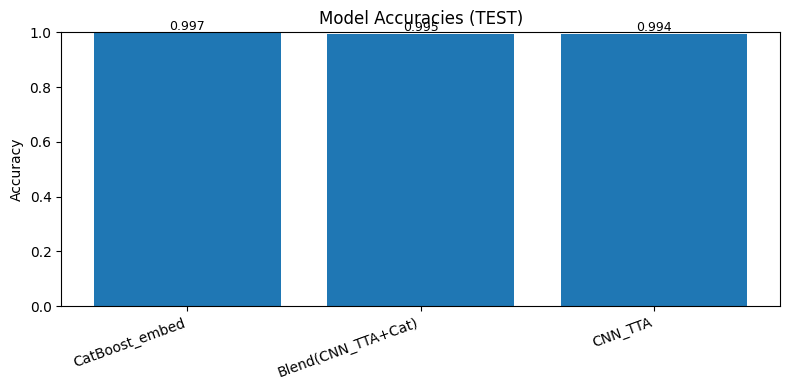

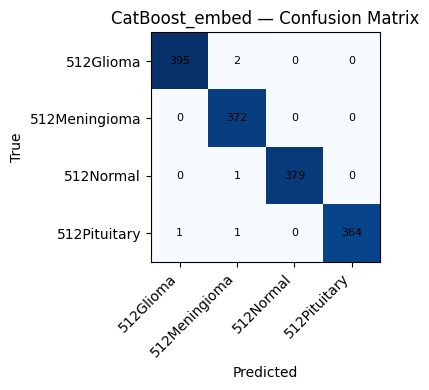

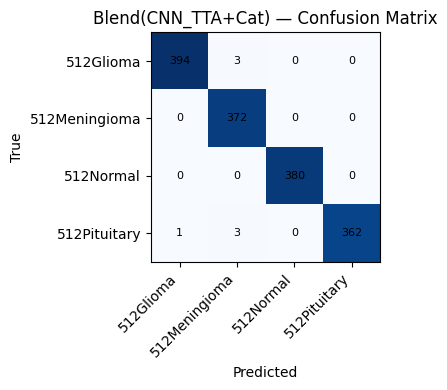

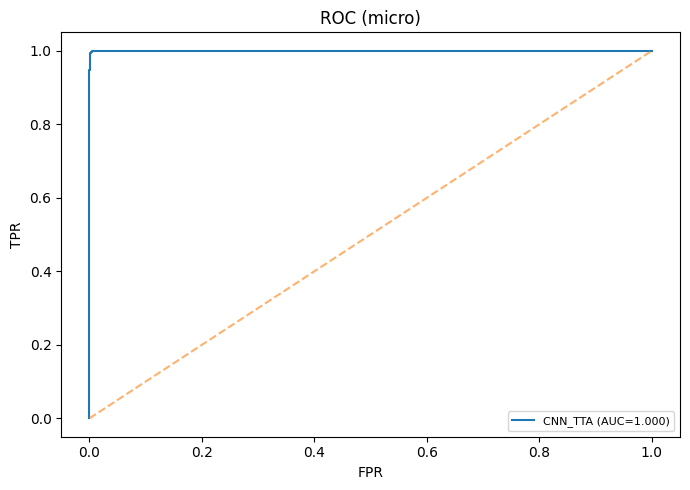

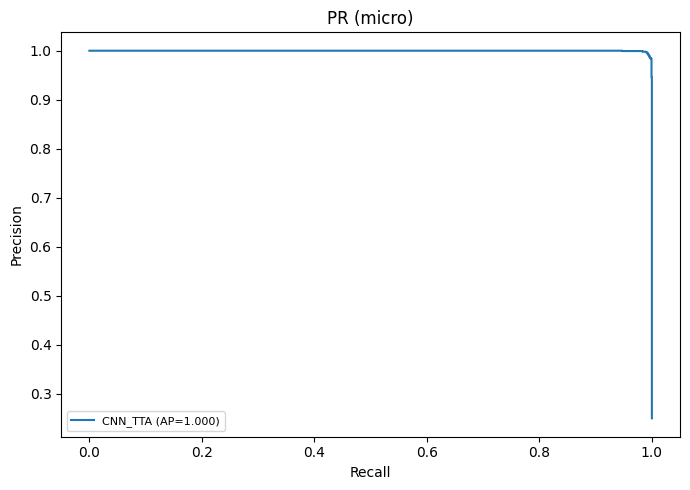

Saved: /content/drive/MyDrive/BrainMRI_Results_Advanced/best_cnn_effb3_final.keras

✅ Final comparison complete. Saved outputs in: /content/drive/MyDrive/BrainMRI_Results_Advanced


In [13]:
# ================= FINAL COMPARISON (ROBUST, LOW-MEM) =================
# Works whether you skipped the ensemble cell or CatBoost, etc.
# Builds a summary table, saves reports, and draws a few light-weight plots.

import os, json, gc, numpy as np, matplotlib.pyplot as plt, itertools, pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve
)

# ---- Guards & setup ----
assert 'test_s2' in globals(), "Need test_s2 dataset."
assert 'class_names' in globals(), "Need class_names."
if 'RUN_DIR' not in globals(): RUN_DIR = "/content/BrainMRI_Results_Final"
os.makedirs(RUN_DIR, exist_ok=True)

FIG_DIR = os.path.join(RUN_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

# ---- Helpers ----
def add_model(reg, name, y_true, pred=None, proba=None):
    if proba is not None and pred is None:
        pred = np.argmax(proba, axis=1)
    if pred is None:
        return
    acc  = accuracy_score(y_true, pred)
    f1m  = f1_score(y_true, pred, average='macro', zero_division=0)
    prm  = precision_score(y_true, pred, average='macro', zero_division=0)
    rcm  = recall_score(y_true, pred, average='macro', zero_division=0)
    reg[name] = {"pred": pred, "proba": proba, "acc": acc, "f1": f1m, "prec": prm, "rec": rcm}

def get_y_from_ds(ds):
    ys = []
    for _, yb in ds:
        y = yb.numpy()
        if y.ndim == 2:  # one-hot
            y = np.argmax(y, axis=1)
        ys.append(y)
    return np.concatenate(ys, 0)

# If y_test already computed earlier, reuse; else compute now
if 'y_test' not in globals():
    y_test = get_y_from_ds(test_s2)

# If you skipped TTA cell, do a quick plain predict (no TTA) to still have a baseline row
def plain_proba(model, ds):
    outs = []
    for xb, _ in ds:
        outs.append(model.predict(xb, verbose=0))
    return np.concatenate(outs, 0)

# ---- Collect whatever models/results exist ----
models = {}

# 1) CNN TTA (preferred) or plain if TTA missing
if 'proba_cnn_tta' in globals():
    add_model(models, "CNN_TTA", y_test, proba=proba_cnn_tta)
elif 'best_cnn' in globals():
    try:
        P_plain = plain_proba(best_cnn, test_s2)
        add_model(models, "CNN_plain", y_test, proba=P_plain)
    except Exception as e:
        print("Skipping CNN baseline:", e)

# 2) Ensemble(3) TTA if present (safe if you skipped Cell 5)
if 'proba_ensemble_tta' in globals():
    add_model(models, "Ensemble(3)_TTA", y_test, proba=proba_ensemble_tta)

# 3) Feature learners (only if you ran those cells)
if 'XGB_TUNED' in globals():
    add_model(models, "CNN+XGB (tuned)", y_test, pred=XGB_TUNED.get("pred"), proba=XGB_TUNED.get("proba"))
if 'SVM_TUNED' in globals():
    add_model(models, "CNN+SVM (tuned)", y_test, pred=SVM_TUNED.get("pred"))
if 'CATBOOST_TUNED' in globals():
    add_model(models, "CatBoost (tuned)", y_test, pred=CATBOOST_TUNED.get("pred"))
if 'pred_cat' in globals():  # from CatBoost embedding cell
    add_model(models, "CatBoost_embed", y_test, pred=pred_cat)
if 'pred_blend' in globals():  # learned blender
    add_model(models, "Blend(CNN_TTA+Cat)", y_test, pred=pred_blend)

# 4) Any other Keras models you may have (optional)
if 'resnet' in globals():
    try:
        P = plain_proba(resnet, test_s2)
        add_model(models, "ResNet50_plain", y_test, proba=P)
    except: pass
if 'mbv3' in globals():
    try:
        P = plain_proba(mbv3, test_s2)
        add_model(models, "MobileNetV3_plain", y_test, proba=P)
    except: pass

if not models:
    raise RuntimeError("No models/probabilities found. Run training/eval cells first.")

# ---- Summary table ----
rows = []
for k, v in models.items():
    rows.append([k, v["acc"], v["f1"], v["prec"], v["rec"], int(v["proba"] is not None)])
summary_df = pd.DataFrame(rows, columns=["Model","Accuracy","F1 (macro)","Precision (macro)","Recall (macro)","Has_Proba"])
summary_df = summary_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(summary_df)

summary_csv = os.path.join(RUN_DIR, "summary_metrics.csv")
summary_df.to_csv(summary_csv, index=False)

# Save per-model classification report & preds/probas
for name, info in models.items():
    rpt = classification_report(y_test, info["pred"], target_names=class_names, digits=4)
    with open(os.path.join(RUN_DIR, f"{name}_report.txt"), "w") as f:
        f.write(rpt)
    np.save(os.path.join(RUN_DIR, f"{name}_pred.npy"), info["pred"])
    if info["proba"] is not None:
        np.save(os.path.join(RUN_DIR, f"{name}_proba.npy"), info["proba"])

# ---- Plots (lightweight) ----
# Accuracy bar
plt.figure(figsize=(max(8, 1.2*len(summary_df)), 4))
plt.bar(summary_df["Model"], summary_df["Accuracy"])
for i, v in enumerate(summary_df["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy"); plt.title("Model Accuracies (TEST)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "accuracy_bar.png"), dpi=180)
plt.show()

# Confusion matrices for top-2 (keeps RAM low)
top_k = min(2, len(summary_df))
for name in summary_df["Model"].tolist()[:top_k]:
    info = models[name]
    cm = confusion_matrix(y_test, info["pred"])
    plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"{name} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"cm_{name}.png"), dpi=180)
    plt.show()

# ROC/PR (micro-average) for up to 4 proba-models to save memory
prob_models = [k for k, v in models.items() if v["proba"] is not None][:4]
if prob_models:
    Y = np.zeros((y_test.shape[0], len(class_names)), dtype=int)
    Y[np.arange(y_test.shape[0]), y_test] = 1

    # ROC micro
    plt.figure(figsize=(7,5))
    for name in prob_models:
        P = models[name]["proba"]
        fpr, tpr, _ = roc_curve(Y.ravel(), P.ravel())
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    plt.plot([0,1],[0,1],'--', alpha=0.6)
    plt.title("ROC (micro)"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "roc_micro.png"), dpi=180)
    plt.show()

    # PR micro
    plt.figure(figsize=(7,5))
    for name in prob_models:
        P = models[name]["proba"]
        pr, rc, _ = precision_recall_curve(Y.ravel(), P.ravel())
        plt.plot(rc, pr, label=f"{name} (AP={auc(rc,pr):.3f})")
    plt.title("PR (micro)"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "pr_micro.png"), dpi=180)
    plt.show()

# ---- Save Keras best model if present ----
def try_save_keras(m, name):
    try:
        path = os.path.join(RUN_DIR, f"{name}.keras")
        m.save(path); print("Saved:", path)
    except Exception as e:
        print(f"Skip saving {name}:", e)

if 'best_cnn' in globals():
    try_save_keras(best_cnn, "best_cnn_effb3_final")

# ---- Run metadata ----
run_meta = {
    "classes": list(class_names),
    "n_test": int(y_test.shape[0]),
    "models": list(models.keys()),
}
with open(os.path.join(RUN_DIR, "run_meta.json"), "w") as f:
    json.dump(run_meta, f, indent=2)

print("\n✅ Final comparison complete. Saved outputs in:", RUN_DIR)

# Light cleanup
gc.collect();
